## Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format

data = pd.read_parquet(r'C:\Users\newbi\Desktop\Project\GDA\cyclistic_cleaned_data.parquet')

In [2]:
df = data.copy()

In [3]:
df.shape

(11774329, 21)

In [4]:
df.dtypes

ride_id                           str
rideable_type                     str
started_at             datetime64[us]
ended_at               datetime64[us]
day_of_week                     int32
holiday_name                      str
season                            str
month                           int32
year                            int32
start_station_name                str
start_station_id                  str
end_station_name                  str
end_station_id                    str
start_lat                     float64
start_lng                     float64
end_lat                       float64
end_lng                       float64
member_casual                     str
duration              timedelta64[us]
duration_min                  float64
duration_hour                 float64
dtype: object

In [5]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at', 'day_of_week',
       'holiday_name', 'season', 'month', 'year', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual', 'duration',
       'duration_min', 'duration_hour'],
      dtype='str')

In [6]:
df.head()

,ride_id,rideable_type,started_at,ended_at,day_of_week,holiday_name,season,month,year,start_station_name,...,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration,duration_min,duration_hour
0,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,0,New Year's Day,Winter,1,2024,On-street,...,Clark St & Wrightwood Ave,TA1305000014,41.95,-87.65,41.93,-87.64,member,0 days 00:07:17,7.28,0.12
1,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,0,New Year's Day,Winter,1,2024,On-street,...,On-street,STREET,41.90,-87.62,41.90,-87.62,casual,0 days 00:03:30,3.50,0.06
2,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,0,New Year's Day,Winter,1,2024,On-street,...,On-street,STREET,41.90,-87.62,41.90,-87.62,casual,0 days 00:03:33,3.55,0.06
3,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,0,New Year's Day,Winter,1,2024,Clinton St & Madison St,...,On-street,STREET,41.88,-87.64,41.89,-87.62,member,0 days 00:21:37,21.62,0.36
4,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,0,New Year's Day,Winter,1,2024,LaSalle St & Illinois St,...,Indiana Ave & Roosevelt Rd,SL-005,41.89,-87.63,41.87,-87.62,member,0 days 00:23:11,23.18,0.39


## Analysis

### Year on Year

In [7]:
ride_count_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].size()
ride_count_yoy

started_at
2024    5728669
2025    5405563
2026     640097
Name: duration_min, dtype: int64

In [8]:
ride_duration_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].sum()
ride_duration_yoy

started_at
2024   101274024.34
2025    88952289.29
2026     8670914.73
Name: duration_min, dtype: float64

In [9]:
ride_mean_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].mean()
ride_mean_yoy

started_at
2024   17.68
2025   16.46
2026   13.55
Name: duration_min, dtype: float64

In [10]:
ride_median_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].median()
ride_median_yoy

started_at
2024   9.94
2025   9.69
2026   7.83
Name: duration_min, dtype: float64

In [11]:
ride_min_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].min()
ride_min_yoy

started_at
2024   1.00
2025   1.00
2026   1.00
Name: duration_min, dtype: float64

In [12]:
ride_max_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].max()
ride_max_yoy

started_at
2024   1559.93
2025   1574.90
2026   1559.95
Name: duration_min, dtype: float64

In [13]:
ride_sd_yoy = df.groupby(df['started_at'].dt.year)['duration_min'].std()
ride_sd_yoy

started_at
2024   61.94
2025   55.82
2026   52.71
Name: duration_min, dtype: float64

In [14]:
df_q1 = df[df['started_at'].dt.month.isin([1,2,3])]
df_q1_group = df_q1.groupby('year').agg(total_ride = ('duration_min','size'),
                                               total_duration = ('duration_min','sum'))
print(df_q1_group)

      total_ride  total_duration
year                            
2024      654819     10319581.48
2025      576538      7323686.05
2026      640097      8670914.73


In [15]:
df_q1 = df[df['started_at'].dt.month.isin([1,2,3])]
df_q1_group = df_q1.groupby(['month','year']).agg(total_ride = ('duration_min','size'),
                                               total_duration = ('duration_min','sum'))
print(df_q1_group)

            total_ride  total_duration
month year                            
1     2024      140537      2180028.98
      2025      135805      1504727.46
      2026      133936      1875759.76
2     2024      219183      3459211.22
      2025      149169      1653641.56
      2026      197432      2431167.11
3     2024      295099      4680341.28
      2025      291564      4165317.03
      2026      308729      4363987.85


### Period lookup

In [16]:
summary_table = df.groupby(['year', 'month']).size().reset_index(name='ride_count')
summary_table['period'] = summary_table.apply(lambda x : f"{int(x['year'])}-{int(x['month']):02d}", axis=1)

print("--- Ride Count Summary Table ---")
print(summary_table[['period', 'ride_count']])

--- Ride Count Summary Table ---
     period  ride_count
0   2024-01      140537
1   2024-02      219183
2   2024-03      295099
3   2024-04      404830
4   2024-05      593708
5   2024-06      693149
6   2024-07      732543
7   2024-08      738864
8   2024-09      800568
9   2024-10      605494
10  2024-11      329628
11  2024-12      175066
12  2025-01      135805
13  2025-02      149169
14  2025-03      291564
15  2025-04      363490
16  2025-05      490253
17  2025-06      659179
18  2025-07      739828
19  2025-08      767379
20  2025-09      696269
21  2025-10      629080
22  2025-11      346963
23  2025-12      136584
24  2026-01      133936
25  2026-02      197432
26  2026-03      308729


In [17]:
df['hour'] = df['started_at'].dt.hour

In [18]:
avg_hourly_rides_duration = df.groupby(['member_casual','hour'])['duration_hour'].size()
avg_hourly_rides_duration

member_casual  hour
casual         0        73645
               1        48229
               2        31139
               3        17344
               4        13850
               5        23917
               6        56262
               7       104912
               8       148930
               9       148589
               10      180426
               11      229358
               12      271007
               13      281153
               14      294585
               15      325996
               16      369971
               17      396855
               18      337167
               19      248629
               20      179993
               21      151340
               22      129765
               23       92632
member         0        66855
               1        40846
               2        23803
               3        16061
               4        18442
               5        73015
               6       216596
               7       424279
               8    

### Cross Analysis

In [19]:
df['member_casual'].value_counts().sort_values(ascending=False)

member_casual
member    7618635
casual    4155694
Name: count, dtype: int64

In [20]:
df['member_casual'].value_counts(normalize=True).sort_values(ascending=False)

member_casual
member   0.65
casual   0.35
Name: proportion, dtype: float64

In [21]:
df['rideable_type'].value_counts().sort_values(ascending=False)

rideable_type
electric_bike       6759701
classic_bike        4877044
electric_scooter     137584
Name: count, dtype: int64

In [22]:
df['rideable_type'].value_counts(normalize=True).sort_values(ascending=False)

rideable_type
electric_bike      0.57
classic_bike       0.41
electric_scooter   0.01
Name: proportion, dtype: float64

In [23]:
df['day_of_week'].value_counts().sort_values(ascending=False)

day_of_week
5    1821813
4    1739418
3    1728057
2    1709669
1    1659428
0    1586627
6    1529317
Name: count, dtype: int64

In [24]:
df['day_of_week'].value_counts(normalize=True).sort_values(ascending=False)

day_of_week
5   0.15
4   0.15
3   0.15
2   0.15
1   0.14
0   0.13
6   0.13
Name: proportion, dtype: float64

In [25]:
df_holiday = df.groupby('holiday_name')['duration_min'].mean().reset_index(name='Avg. Duration (min)')
df_holiday.sort_values('Avg. Duration (min)', ascending=False)

,holiday_name,Avg. Duration (min)
4,Independence Day,24.71
6,Labor Day,23.33
9,Memorial Day,22.72
1,Christmas Day,20.90
8,Martin Luther King Jr. Day,20.38
5,Juneteenth National Independence Day,19.45
10,New Year's Day,18.47
11,None,16.84
2,Columbus Day,16.21
14,Washington's Birthday,14.84


In [26]:
df_member_casual_trip = df.groupby(['year','member_casual']).agg(ride_count=('duration_min','size'),
                                                                 duration = ('duration_min','sum'))
print(df_member_casual_trip)

                    ride_count    duration
year member_casual                        
2024 casual            2086078 53948419.41
     member            3642591 47325604.93
2025 casual            1920461 45151015.34
     member            3485102 43801273.95
2026 casual             149155  2895745.01
     member             490942  5775169.72


In [27]:
df_member_casual_trip_by_weekday = df.groupby(['day_of_week','member_casual']).agg(ride_count=('duration_min','size'), 
                                                                                   duration = ('duration_min','sum'))
print(df_member_casual_trip_by_weekday)

                           ride_count    duration
day_of_week member_casual                        
0           casual             489229 11716750.79
            member            1097398 13438093.78
1           casual             460915  9716439.37
            member            1198513 14668536.52
2           casual             492018 10441983.75
            member            1217651 14959904.10
3           casual             524008 11219347.63
            member            1204049 14706696.82
4           casual             635005 15179496.57
            member            1104413 13834602.27
5           casual             856173 23675808.51
            member             965640 13551038.83
6           casual             698346 20045353.15
            member             830971 11743176.27


In [28]:
df_member_casual_trip_by_month = df.groupby(['month','member_casual']).agg(ride_count=('duration_min','size'), 
                                                                           duration = ('duration_min','sum'))
print(df_member_casual_trip_by_month)

                     ride_count    duration
month member_casual                        
1     casual              71188  1309956.28
      member             339090  4250559.93
2     casual             113458  2289120.73
      member             452326  5254899.15
3     casual             248712  5605443.90
      member             646680  7604202.27
4     casual             233535  5791970.34
      member             534785  6468038.15
5     casual             399833 10750756.03
      member             684128  8970804.99
6     casual             570523 15747473.30
      member             781805 10689997.69
7     casual             619801 16838175.61
      member             852570 11749486.34
8     casual             632592 16181818.16
      member             873651 11778576.42
9     casual             590086 13124517.37
      member             906751 11484288.88
10    casual             425592  9617128.61
      member             808982 10016361.08
11    casual             185735 

In [29]:
df_member_casual_trip_by_season = df.groupby(['season','member_casual']).agg(ride_count=('duration_min','size'), 
                                                                             duration = ('duration_min','sum'))
print(df_member_casual_trip_by_season)

                      ride_count    duration
season member_casual                        
Fall   casual             811006 17223310.31
       member            1751782 21182479.16
Spring casual            1081521 28261701.28
       member            1980511 25302899.94
Summer casual            1918238 49263107.67
       member            2661375 35763709.55
Winter casual             344929  7247060.51
       member            1224967 14652959.94


In [30]:
df_member_casual_trip_by_rideable = df.groupby(['rideable_type','member_casual']).agg(ride_count=('duration_min','size'), 
                                                                             duration = ('duration_min','sum'))
df_member_casual_trip_by_rideable

ride_count    duration
rideable_type    member_casual                        
classic_bike     casual            1685128 65280246.27
                 member            3191916 46826380.64
electric_bike    casual            2389116 35699307.49
                 member            4370585 49589654.61
electric_scooter casual              81450  1015626.01
                 member              56134   486013.34

### Station

In [31]:
df['start_station_name'].value_counts(ascending=False).head(20)

start_station_name
On-street                             2206194
Streeter Dr & Grand Ave                 94836
DuSable Lake Shore Dr & Monroe St       84854
Kingsbury St & Kinzie St                79460
Michigan Ave & Oak St                   75984
DuSable Lake Shore Dr & North Blvd      73835
Clark St & Elm St                       67328
Clinton St & Washington Blvd            67000
Clinton St & Madison St                 64591
Wells St & Concord Ln                   62089
Millennium Park                         61803
Wells St & Elm St                       59901
Canal St & Madison St                   59704
Theater on the Lake                     57737
State St & Chicago Ave                  56459
Clinton St & Jackson Blvd               53337
Wells St & Huron St                     52519
Clark St & Armitage Ave                 51009
Dearborn St & Erie St                   50792
Wabash Ave & Grand Ave                  50439
Name: count, dtype: int64

In [32]:
df['end_station_name'].value_counts(ascending=False).head(20)

end_station_name
On-street                             2262803
Streeter Dr & Grand Ave                 96299
DuSable Lake Shore Dr & Monroe St       82161
DuSable Lake Shore Dr & North Blvd      78821
Kingsbury St & Kinzie St                78626
Michigan Ave & Oak St                   75889
Clinton St & Washington Blvd            67683
Clark St & Elm St                       66325
Clinton St & Madison St                 65876
Wells St & Concord Ln                   62670
Millennium Park                         62252
Canal St & Madison St                   60091
Theater on the Lake                     59456
Wells St & Elm St                       59371
State St & Chicago Ave                  56847
Clinton St & Jackson Blvd               54352
Clark St & Armitage Ave                 51476
Wabash Ave & Grand Ave                  50280
Dearborn St & Erie St                   50137
Clark St & Lincoln Ave                  50122
Name: count, dtype: int64

### On-Street

In [33]:
on_street = (df['start_station_name'] == 'On-street') | (df['end_station_name'] == 'On-street')
df_on_street = df[on_street].reset_index()
df_on_street['ride_id'].count()

np.int64(3482892)

In [34]:
df_on_street['rideable_type'].value_counts()

rideable_type
electric_bike       3378601
electric_scooter      90638
classic_bike          13653
Name: count, dtype: int64

In [35]:
df_street = df[df['start_station_name'] == 'On-street'].groupby(['end_station_name','rideable_type']).size()
df_street.sort_values(ascending=0).head(10)

end_station_name              rideable_type   
On-street                     electric_bike       947685
                              electric_scooter     38420
Kingsbury St & Kinzie St      electric_bike         8699
Wells St & Concord Ln         electric_bike         8131
Wilton Ave & Belmont Ave      electric_bike         7567
Wells St & Elm St             electric_bike         7524
Clark St & Elm St             electric_bike         7523
Clinton St & Washington Blvd  electric_bike         7373
Broadway & Barry Ave          electric_bike         7259
State St & Chicago Ave        electric_bike         7231
dtype: int64

In [36]:
df_street = df[df['end_station_name'] == 'On-street'].groupby(['start_station_name','rideable_type']).size()
df_street.sort_values(ascending=0).head(10)

start_station_name        rideable_type   
On-street                 electric_bike       947685
                          electric_scooter     38420
Kingsbury St & Kinzie St  electric_bike         9032
Wells St & Concord Ln     electric_bike         8803
Wells St & Elm St         electric_bike         8425
Wilton Ave & Belmont Ave  electric_bike         8139
Clark St & Elm St         electric_bike         7932
Broadway & Barry Ave      electric_bike         7512
State St & Chicago Ave    electric_bike         7412
Clark St & Armitage Ave   electric_bike         6960
dtype: int64

## PLOT

In [ ]:
# color and theme setting.

my_colors = [ "#7ead8c", "#ffde59","#4095a5"]
sns.set_theme(
    style="whitegrid",
    palette=sns.color_palette(my_colors),
    font="kanit",
    rc={"lines.linewidth": 0.5}
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.autolayout'] = True

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11774329 entries, 0 to 11774328
Data columns (total 22 columns):
 #   Column              Dtype          
---  ------              -----          
 0   ride_id             str            
 1   rideable_type       str            
 2   started_at          datetime64[us] 
 3   ended_at            datetime64[us] 
 4   day_of_week         int32          
 5   holiday_name        str            
 6   season              str            
 7   month               int32          
 8   year                int32          
 9   start_station_name  str            
 10  start_station_id    str            
 11  end_station_name    str            
 12  end_station_id      str            
 13  start_lat           float64        
 14  start_lng           float64        
 15  end_lat             float64        
 16  end_lng             float64        
 17  member_casual       str            
 18  duration            timedelta64[us]
 19  duration_min        float64   

### Ride duration and Ride count

In [39]:
df['member_casual'].value_counts(normalize=True)

member_casual
member   0.65
casual   0.35
Name: proportion, dtype: float64

In [40]:
df['rideable_type'].value_counts(normalize=True)

rideable_type
electric_bike      0.57
classic_bike       0.41
electric_scooter   0.01
Name: proportion, dtype: float64

### Ride type vs Member_casual

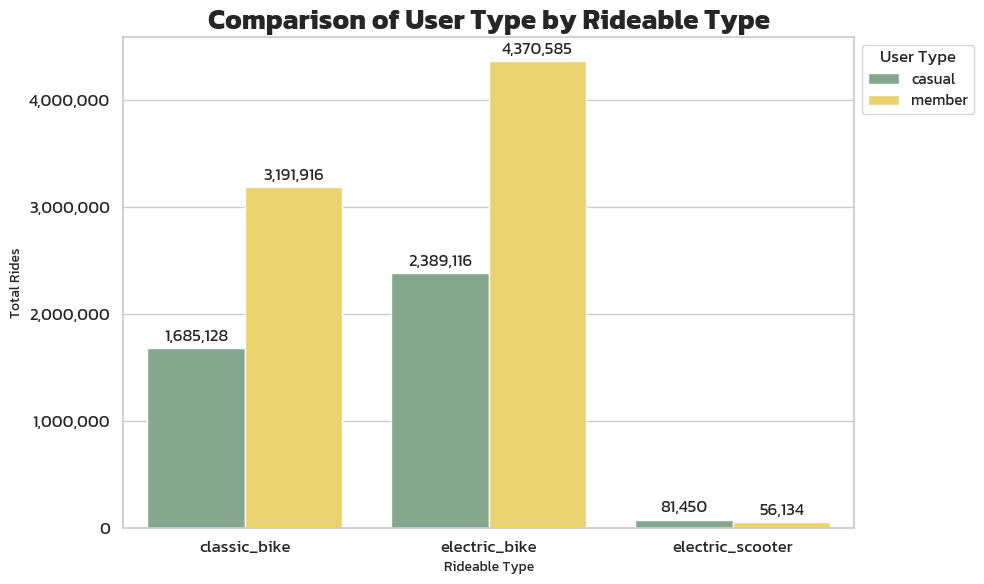

In [41]:
chart_data = df.groupby(['rideable_type', 'member_casual']).size().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='rideable_type', 
    y='ride_count', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of User Type by Rideable Type')
plt.xlabel('Rideable Type')
plt.ylabel('Total Rides')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc : "{:,}".format(int(x))))

plt.show()

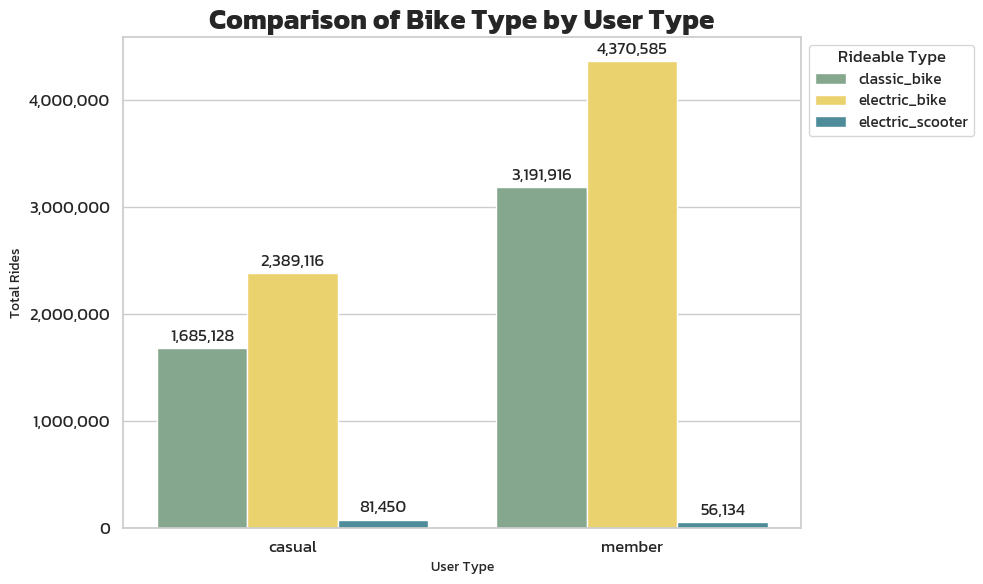

In [42]:
chart_data = df.groupby(['member_casual', 'rideable_type']).size().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='member_casual', 
    y='ride_count', 
    hue='rideable_type', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of Bike Type by User Type')
plt.xlabel('User Type')
plt.ylabel('Total Rides')
plt.legend(title='Rideable Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

### Weekdays compare

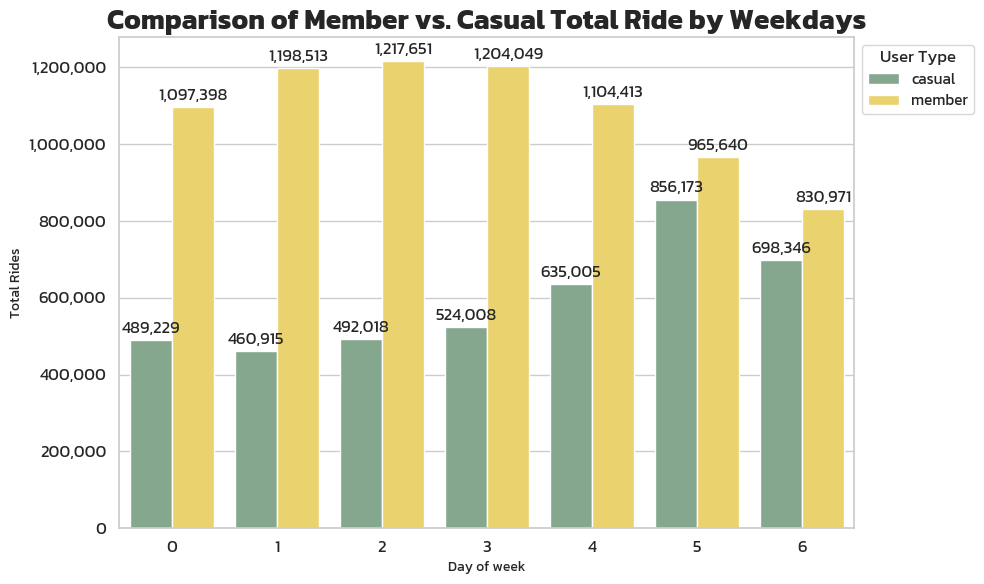

In [43]:
chart_data = df.groupby(['day_of_week','member_casual']).size().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='day_of_week', 
    y='ride_count', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of Member vs. Casual Total Ride by Weekdays')
plt.xlabel('Day of week')
plt.ylabel('Total Rides')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

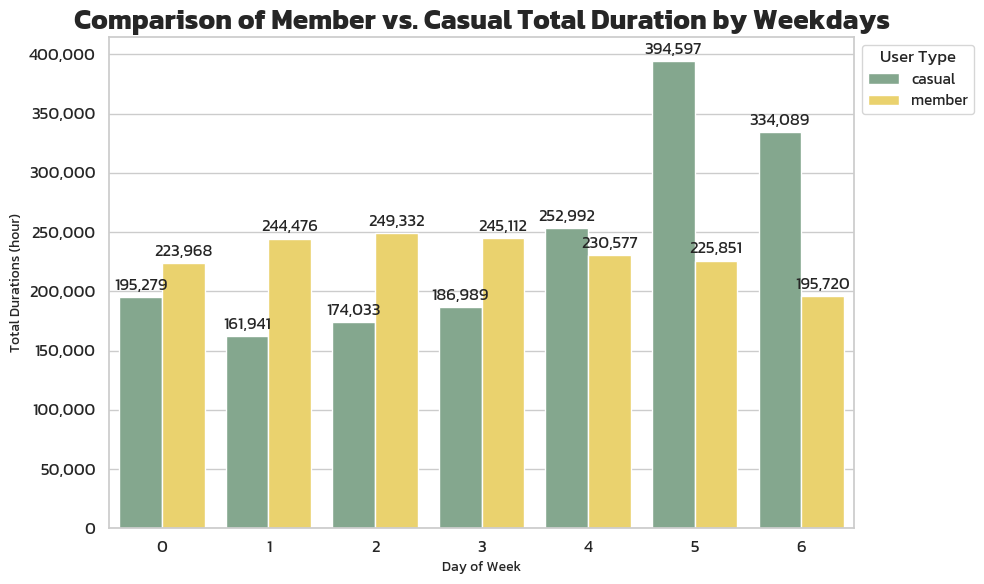

In [44]:
chart_data = df.groupby(['day_of_week','member_casual'])['duration_hour'].sum().reset_index(name='ride_duration')

ax = sns.barplot(
    data=chart_data, 
    x='day_of_week', 
    y='ride_duration', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of Member vs. Casual Total Duration by Weekdays')
plt.xlabel('Day of Week')
plt.ylabel('Total Durations (hour)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

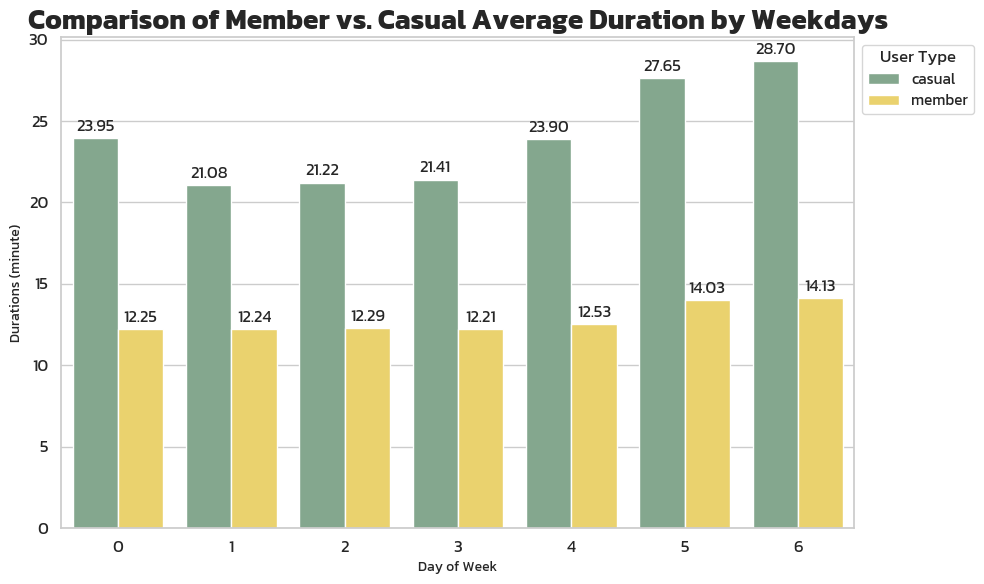

In [45]:
chart_data = df.groupby(['day_of_week','member_casual'])['duration_min'].mean().reset_index(name='ride_duration')

ax = sns.barplot(
    data=chart_data, 
    x='day_of_week', 
    y='ride_duration', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3)

plt.title('Comparison of Member vs. Casual Average Duration by Weekdays')
plt.xlabel('Day of Week')
plt.ylabel('Durations (minute)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

### Monthly and Season compare

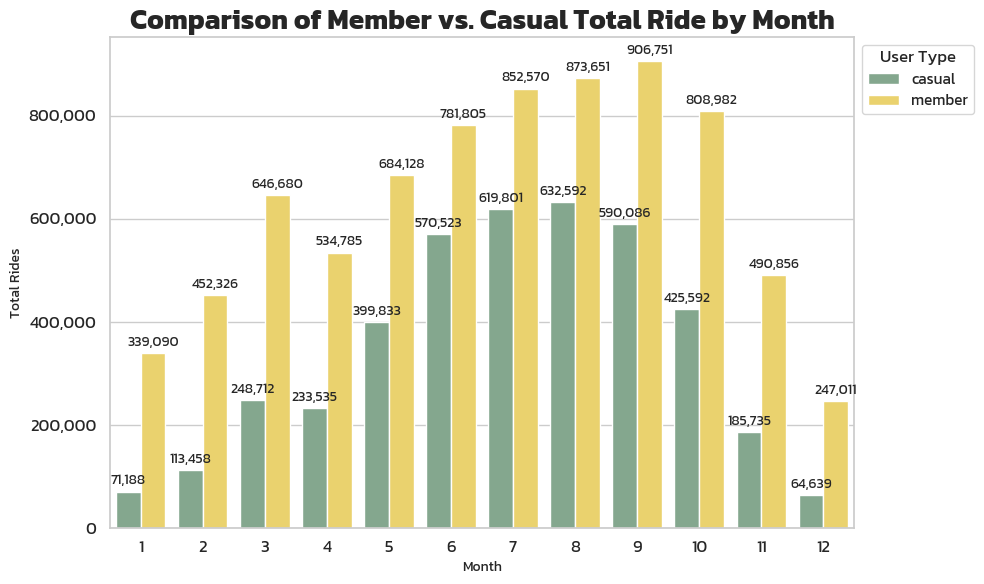

In [46]:
chart_data = df.groupby(['month','member_casual'])['duration_hour'].size().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='month', 
    y='ride_count', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10)

plt.title('Comparison of Member vs. Casual Total Ride by Month')
plt.xlabel('Month')
plt.ylabel('Total Rides')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

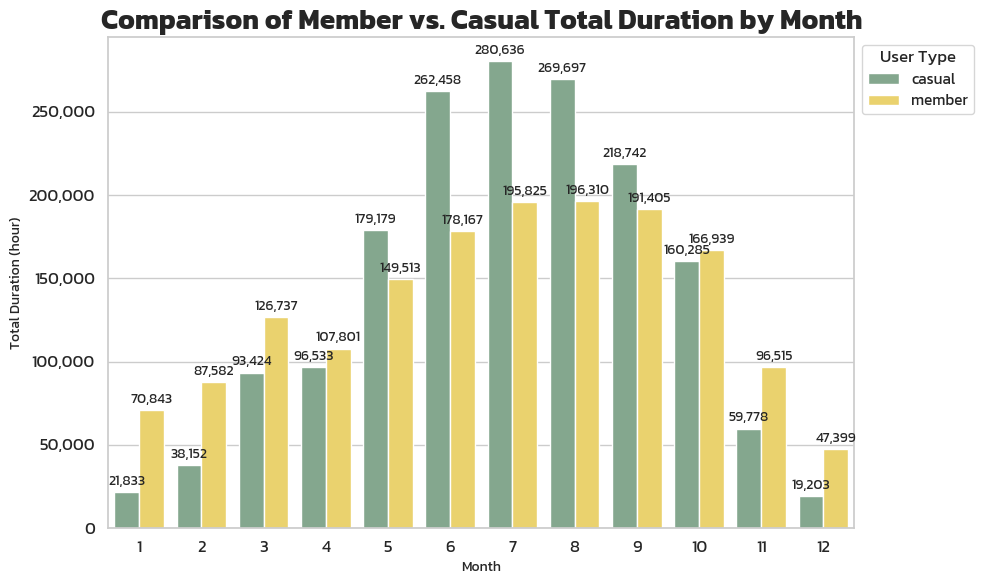

In [47]:
chart_data = df.groupby(['month','member_casual'])['duration_hour'].sum().reset_index(name='total_duration')

ax = sns.barplot(
    data=chart_data, 
    x='month', 
    y='total_duration', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10)

plt.title('Comparison of Member vs. Casual Total Duration by Month')
plt.xlabel('Month')
plt.ylabel('Total Duration (hour)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

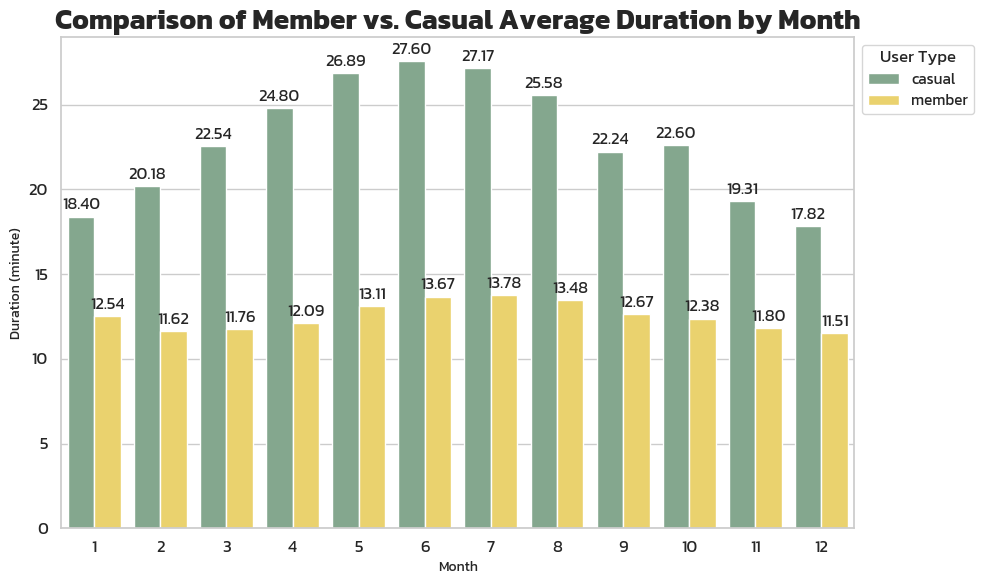

In [48]:
chart_data = df.groupby(['month','member_casual'])['duration_min'].mean().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='month', 
    y='ride_count', 
    hue='member_casual', 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3)

plt.title('Comparison of Member vs. Casual Average Duration by Month')
plt.xlabel('Month')
plt.ylabel('Duration (minute)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

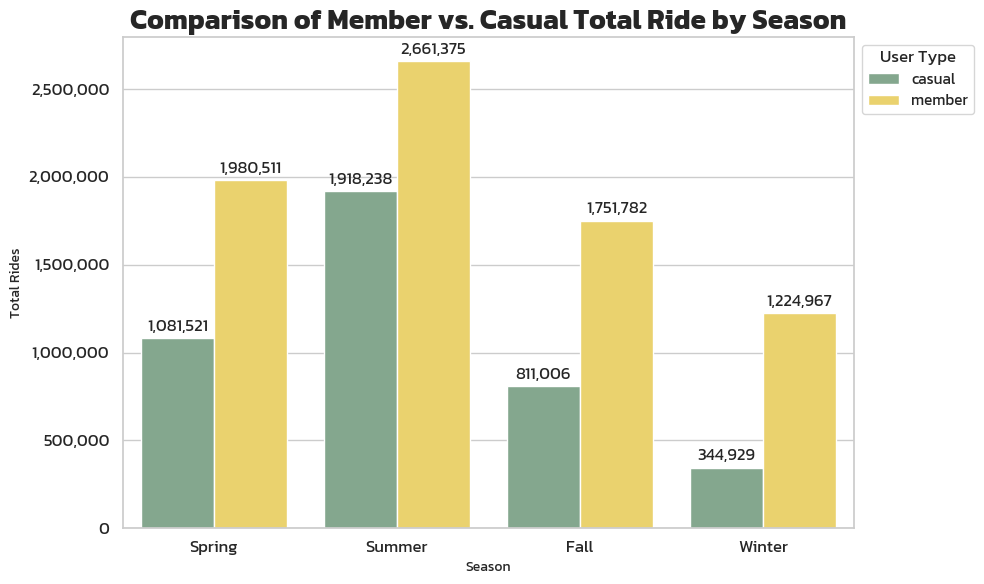

In [49]:
chart_data = df.groupby(['season','member_casual'])['duration_hour'].size().reset_index(name='ride_count')

ax = sns.barplot(
    data=chart_data, 
    x='season', 
    y='ride_count', 
    hue='member_casual',
    order=['Spring', 'Summer', 'Fall', 'Winter'] 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of Member vs. Casual Total Ride by Season')
plt.xlabel('Season')
plt.ylabel('Total Rides')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

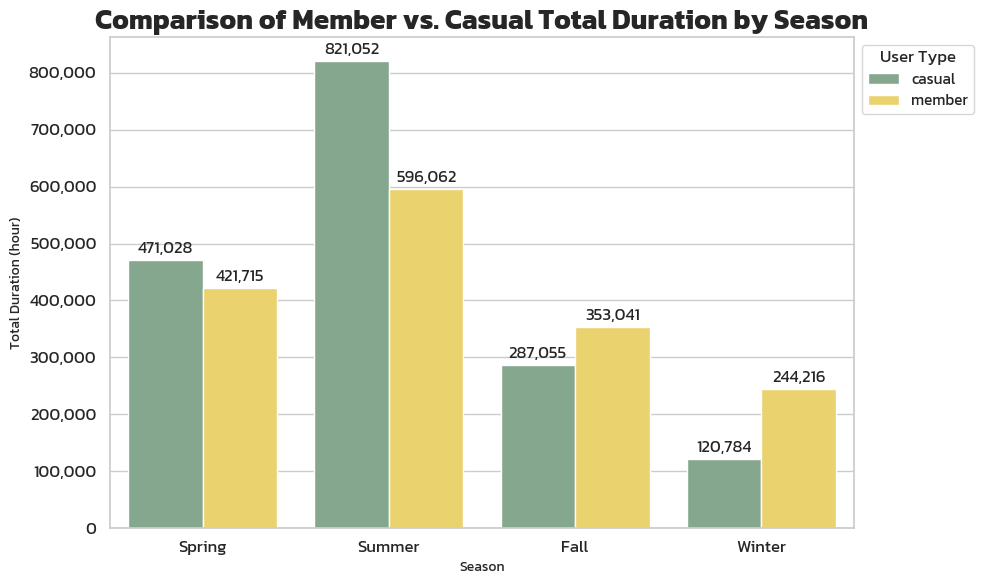

In [50]:
chart_data = df.groupby(['season','member_casual'])['duration_hour'].sum().reset_index(name='ride_duration')

ax = sns.barplot(
    data=chart_data, 
    x='season', 
    y='ride_duration', 
    hue='member_casual', 
    order=['Spring', 'Summer', 'Fall', 'Winter']
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title('Comparison of Member vs. Casual Total Duration by Season')
plt.xlabel('Season')
plt.ylabel('Total Duration (hour)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

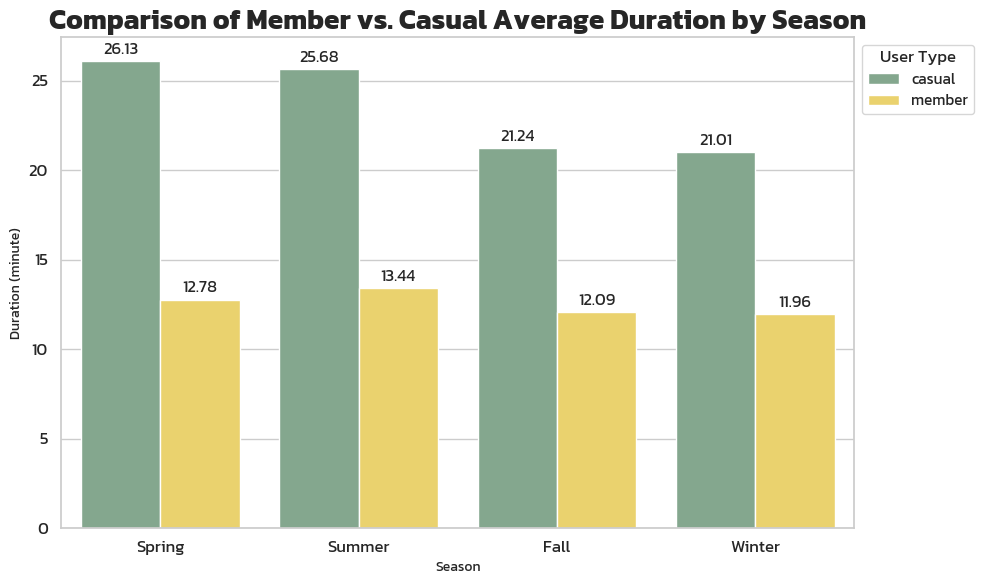

In [51]:
chart_data = df.groupby(['season','member_casual'])['duration_min'].mean().reset_index(name='ride_duration')

ax = sns.barplot(
    data=chart_data, 
    x='season', 
    y='ride_duration', 
    hue='member_casual', 
    order=['Spring', 'Summer', 'Fall', 'Winter']
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3)

plt.title('Comparison of Member vs. Casual Average Duration by Season')
plt.xlabel('Season')
plt.ylabel('Duration (minute)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

### Hourly Compare

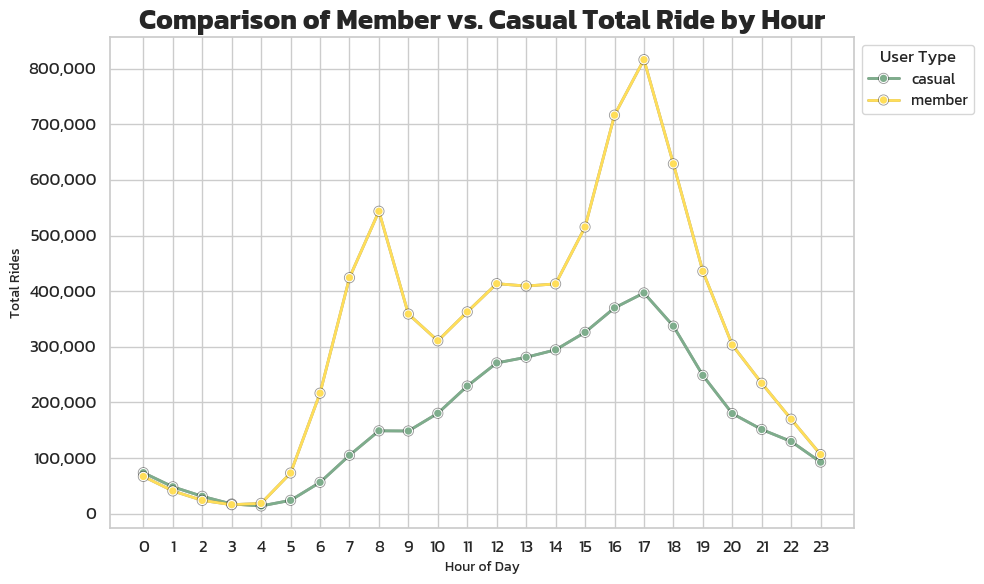

In [52]:
import matplotlib.patheffects as path_effects

chart_data = df.groupby(['hour','member_casual']).size().reset_index(name='ride_count')

ax = sns.lineplot(
    data=chart_data, 
    x='hour', 
    y='ride_count', 
    hue='member_casual',
    marker='o',
    linewidth=2
)

for line in ax.lines:
    line.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black', alpha=0.4), 
        path_effects.Normal()
    ])

plt.xticks(range(0, 24))
plt.title('Comparison of Member vs. Casual Total Ride by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Rides')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

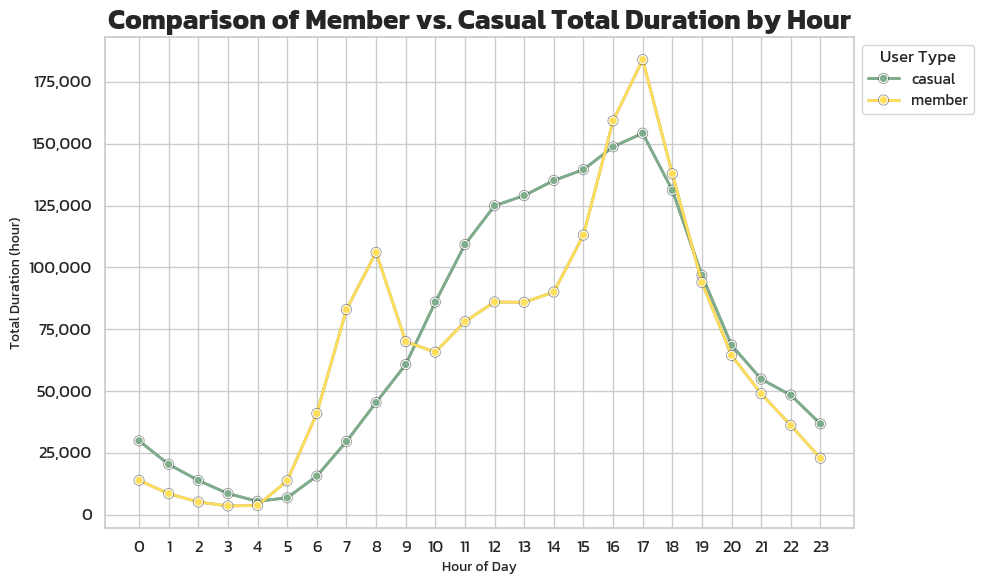

In [53]:
chart_data = df.groupby(['hour','member_casual'])['duration_hour'].sum().reset_index(name='ride_count')

ax = sns.lineplot(
    data=chart_data, 
    x='hour', 
    y='ride_count', 
    hue='member_casual',
    marker='o',
    linewidth=2
)

for line in ax.lines:
    line.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black', alpha=0.4), 
        path_effects.Normal()
    ])
    
plt.xticks(range(0, 24))
plt.title('Comparison of Member vs. Casual Total Duration by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Duration (hour)')
plt.legend(title='User Type', bbox_to_anchor=(1, 1), loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.show()

### Station and Map

In [54]:
top_start_station = df['start_station_name'].value_counts(ascending=False).head(10)
top_start_station.reset_index()
top_start_station

start_station_name
On-street                             2206194
Streeter Dr & Grand Ave                 94836
DuSable Lake Shore Dr & Monroe St       84854
Kingsbury St & Kinzie St                79460
Michigan Ave & Oak St                   75984
DuSable Lake Shore Dr & North Blvd      73835
Clark St & Elm St                       67328
Clinton St & Washington Blvd            67000
Clinton St & Madison St                 64591
Wells St & Concord Ln                   62089
Name: count, dtype: int64

In [55]:
top_end_station = df['end_station_name'].value_counts(ascending=False).head(10)
top_end_station.reset_index()
top_end_station

end_station_name
On-street                             2262803
Streeter Dr & Grand Ave                 96299
DuSable Lake Shore Dr & Monroe St       82161
DuSable Lake Shore Dr & North Blvd      78821
Kingsbury St & Kinzie St                78626
Michigan Ave & Oak St                   75889
Clinton St & Washington Blvd            67683
Clark St & Elm St                       66325
Clinton St & Madison St                 65876
Wells St & Concord Ln                   62670
Name: count, dtype: int64

In [56]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at', 'day_of_week',
       'holiday_name', 'season', 'month', 'year', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual', 'duration',
       'duration_min', 'duration_hour', 'hour'],
      dtype='str')

In [57]:
# Map
import plotly.express as px

In [58]:
# start station all user
df_all_start_station = df[df['start_station_name'] != 'On-street'].groupby('start_station_name').agg(
                                                      lat=('start_lat','mean'),
                                                      lng=('start_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_all_start_station.head(10), hover_name="start_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [59]:
df_all_start_station.head(10)

,start_station_name,lat,lng,duration,ride
1893,Streeter Dr & Grand Ave,41.89,-87.61,55805.52,94836
337,DuSable Lake Shore Dr & Monroe St,41.88,-87.62,49446.68,84854
792,Michigan Ave & Oak St,41.90,-87.62,41456.28,75984
799,Millennium Park,41.88,-87.62,37409.35,61803
338,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,31521.60,73835
1898,Theater on the Lake,41.93,-87.63,27780.79,57737
341,Dusable Harbor,41.89,-87.61,27059.70,46890
1782,Shedd Aquarium,41.87,-87.62,23633.38,47405
787,Michigan Ave & 8th St,41.87,-87.62,19749.85,38988
794,Michigan Ave & Washington St,41.88,-87.62,19583.10,48254


In [60]:
# end station all user
df_all_end_station = df[df['end_station_name'] != 'On-street'].groupby('end_station_name').agg(
                                                      lat=('end_lat','mean'),
                                                      lng=('end_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_all_end_station.head(10), hover_name="end_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [61]:
df_all_end_station.head(10)

,end_station_name,lat,lng,duration,ride
1895,Streeter Dr & Grand Ave,41.89,-87.61,52385.95,96299
338,DuSable Lake Shore Dr & Monroe St,41.88,-87.62,44231.65,82161
792,Michigan Ave & Oak St,41.90,-87.62,37341.51,75889
339,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,32710.85,78821
799,Millennium Park,41.88,-87.62,30099.39,62252
1900,Theater on the Lake,41.93,-87.63,27669.79,59456
342,Dusable Harbor,41.89,-87.61,21982.86,45779
1784,Shedd Aquarium,41.87,-87.62,19592.62,45536
854,Navy Pier,41.89,-87.61,18790.96,38075
820,Montrose Harbor,41.96,-87.64,17869.06,37158


In [62]:
# member start staion
df_member_start_station = df[(df['start_station_name'] != 'On-street') & (df['member_casual'] == 'member')].groupby('start_station_name').agg(
                                                      lat=('start_lat','mean'),
                                                      lng=('start_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_member_start_station.head(10), hover_name="start_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [63]:
df_member_start_station.head(10)

,start_station_name,lat,lng,duration,ride
243,Clinton St & Washington Blvd,41.88,-87.64,10625.10,54945
591,Kingsbury St & Kinzie St,41.89,-87.64,9473.52,60113
338,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,9462.37,31277
209,Clark St & Elm St,41.90,-87.63,9442.44,47049
239,Clinton St & Madison St,41.88,-87.64,9347.28,49135
788,Michigan Ave & Oak St,41.90,-87.62,9206.93,28091
153,Canal St & Madison St,41.88,-87.64,9013.75,44934
1872,Theater on the Lake,41.93,-87.63,8908.68,24914
237,Clinton St & Jackson Blvd,41.88,-87.64,7899.94,41437
1943,Wells St & Concord Ln,41.91,-87.63,7897.96,41207


In [64]:
# casual start station
df_casual_start_station = df[(df['start_station_name'] != 'On-street') & (df['member_casual'] == 'casual')].groupby('start_station_name').agg(
                                                      lat=('start_lat','mean'),
                                                      lng=('start_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_casual_start_station.head(10), hover_name="start_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [65]:
df_casual_start_station.head(10)

,start_station_name,lat,lng,duration,ride
1760,Streeter Dr & Grand Ave,41.89,-87.61,48309.90,73781
336,DuSable Lake Shore Dr & Monroe St,41.88,-87.62,42096.19,66271
790,Michigan Ave & Oak St,41.90,-87.62,32249.35,47893
797,Millennium Park,41.88,-87.62,31363.21,42148
340,Dusable Harbor,41.89,-87.61,22495.64,34397
337,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,22059.23,42558
1649,Shedd Aquarium,41.87,-87.62,20513.71,38581
1765,Theater on the Lake,41.93,-87.63,18872.11,32823
851,Navy Pier,41.89,-87.61,16433.16,29521
785,Michigan Ave & 8th St,41.87,-87.62,16103.05,25012


In [66]:
# member end station
df_member_end_station = df[(df['end_station_name'] != 'On-street') & (df['member_casual'] == 'member')].groupby('end_station_name').agg(
                                                      lat=('end_lat','mean'),
                                                      lng=('end_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_member_end_station.head(10), hover_name="end_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [67]:
df_member_end_station.head(10)

,end_station_name,lat,lng,duration,ride
210,Clark St & Elm St,41.90,-87.63,9450.20,47758
240,Clinton St & Madison St,41.88,-87.64,8955.64,51169
339,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,8949.63,30085
244,Clinton St & Washington Blvd,41.88,-87.64,8762.33,55176
1883,Theater on the Lake,41.93,-87.63,8735.77,23772
593,Kingsbury St & Kinzie St,41.89,-87.64,8618.09,60683
791,Michigan Ave & Oak St,41.90,-87.62,8599.38,26860
338,DuSable Lake Shore Dr & Monroe St,41.88,-87.62,7838.63,20130
1954,Wells St & Concord Ln,41.91,-87.63,7832.28,41728
1856,State St & Chicago Ave,41.90,-87.63,7435.48,42272


In [68]:
# casual end station
df_casual_end_station = df[(df['end_station_name'] != 'On-street') & (df['member_casual'] == 'casual')].groupby('end_station_name').agg(
                                                      lat=('end_lat','mean'),
                                                      lng=('end_lng','mean'),
                                                      duration=('duration_hour','sum'),
                                                      ride=('ride_id','size')).reset_index().sort_values(by='duration',ascending=False)

fig = px.scatter_map(df_casual_end_station.head(10), hover_name="end_station_name", lat="lat", lon="lng", size="ride", color="duration",
                     color_continuous_scale = px.colors.sequential.haline, size_max=10, zoom=10)
fig.show()

In [69]:
df_casual_end_station.head(10)

,end_station_name,lat,lng,duration,ride
1786,Streeter Dr & Grand Ave,41.89,-87.61,46020.88,78604
337,DuSable Lake Shore Dr & Monroe St,41.88,-87.62,36393.02,62031
787,Michigan Ave & Oak St,41.90,-87.62,28742.13,49029
794,Millennium Park,41.88,-87.62,25237.58,44883
338,DuSable Lake Shore Dr & North Blvd,41.91,-87.63,23761.23,48736
1791,Theater on the Lake,41.93,-87.63,18934.02,35684
341,Dusable Harbor,41.89,-87.61,17192.11,30807
849,Navy Pier,41.89,-87.61,16249.43,30274
1675,Shedd Aquarium,41.87,-87.62,16006.49,34480
815,Montrose Harbor,41.96,-87.64,12242.78,21341
